# Counterfactuals — Pendulum

DDIM inversion + intervention sampling for the pendulum benchmark with the
Causal-Adapter (SD1.5) MCPL-pretrained pseudo tokens. Common pipeline setup
lives in `inference_utils.py`; this notebook only owns the dataset loader and
intervention loop.

In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('/projects/dsai/se_aieng/cai/causal/workspace/Causal-Adapter/causal-adapter-sd15')

import os
import random

import numpy as np
import torch
from PIL import Image
from torchvision import transforms

from causal_modules.ddim_modules import sample, ddim_editing, save_images_grid
from inference_utils import build_transforms, load_causal_adapter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'inference_utils'

## 1. Configuration

All hard-coded paths live in this cell. The `controlnet`/`text_embedding`
pair must come from the same training run; `scm_path` is optional and only
needed when the SCM head was pretrained separately via `SCM_modeling`.

In [18]:
DATASET = 'pendulum'
SIZE = 256

BASE_MODEL_PATH = '/projects/dsai/se_aieng/cai/causal/workspace/causaledit/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce'

RUN_DIR = '/projects/dsai/se_aieng/cai/causal/workspace/causaledit/MCPL-diffuser/logs/logs_pendulum_all/2025-06-02T11-43-33-controlnet_textcond_contrast_gaussianfloatgeneration_text_global_after'
STEPS = 20000
CONTROLNET_PATH      = f'{RUN_DIR}/controlnet-steps-{STEPS}.safetensors'
TEXT_EMBEDDING_PATH  = f'{RUN_DIR}/learned_embeds-steps-{STEPS}.safetensors'
SCM_PATH             = '/projects/dsai/se_aieng/cai/causal/workspace/causaledit/MCPL-diffuser/logs/logs_pendulum_all/2025-05-12T12-03-40-causalnet_pretrain/best_model.pt'

DATA_ROOT = '/projects/dsai/se_aieng/cai/causal/workspace/causaledit/MCPL-diffuser/dataset/causal_data2/pendulum/train'

## 2. Build pipeline + transforms

In [19]:
image_transforms, original_transforms, _ = build_transforms(DATASET, size=SIZE)

assets = load_causal_adapter(
    DATASET,
    base_model_path=BASE_MODEL_PATH,
    controlnet_path=CONTROLNET_PATH,
    text_embedding_path=TEXT_EMBEDDING_PATH,
    scm_path=SCM_PATH,
)
pipe              = assets.pipe
device            = assets.device
prompt            = assets.prompt
presudo_words     = assets.presudo_words
presudo_list      = assets.presudo_list
presudo_token_ids = assets.presudo_token_ids

NameError: name 'build_transforms' is not defined

## 3. Load a pendulum sample

Pendulum filenames encode the four causal attributes (pendulum angle, light
angle, shadow length, shadow position). We invert the same per-attribute
Gaussian normalization used during training.

Loaded image: /projects/dsai/se_aieng/cai/causal/workspace/causaledit/MCPL-diffuser/dataset/causal_data2/pendulum/train/a_-14_130_6.796277847829037_12.206641020524199.png
Raw label: [-14.0, 130.0, 6.796277847829037, 12.206641020524199]
Normalized label: [-0.3809524   0.59090906 -0.1563827   0.15083013]


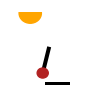

In [20]:
def normalize_label_gaussian(label):
    # scale shape: (4, 2) -> [mean, std-like spread] used at training time.
    scale = np.array([[2, 42], [104, 44], [7.5, 4.5], [11, 8]])
    return ((label - scale[:, 0]) / scale[:, 1]).astype(np.float32)


def load_pendulum_sample(data_root=DATA_ROOT, img_path=None, device=device):
    if img_path is None:
        files = [f for f in os.listdir(data_root) if f.endswith('.png')]
        img_path = os.path.join(data_root, random.choice(files))

    label_values = list(map(float, os.path.basename(img_path)[:-4].split('_')[1:]))
    norm_label = normalize_label_gaussian(np.array(label_values))
    image = Image.open(img_path)

    print(f'Loaded image: {img_path}')
    print(f'Raw label: {label_values}')
    print(f'Normalized label: {norm_label}')
    return image, torch.tensor(norm_label).unsqueeze(0).to(device).float()


img, label = load_pendulum_sample()
img

## 4. DDIM inversion + reconstruction

100%|███████████████████████████████████████████| 50/50 [00:07<00:00,  6.87it/s]


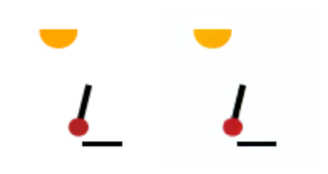

In [21]:
image = img.convert('RGB') if img.mode != 'RGB' else img
original_img = original_transforms(image.copy())
condition_image = image.copy()
image_t = image_transforms(image)

set_guidance_scale = 1.0
num_steps = 50

final_im, inverted_latents, _, uncond_embeddings = ddim_editing(
    pipe,
    image_t.unsqueeze(0),
    label.clone(),
    presudo_token_ids,
    prompt,
    num_steps=num_steps,
    invert_guidance_scale=1.0,
    set_guidance_scale=set_guidance_scale,
    intervention_indx=None,
    intervention_values=None,
    return_PIL=True,
)
save_images_grid([[original_img, final_im[0]]], (1, 2), None)

## 5. Per-attribute intervention sweep

In [22]:
import matplotlib.pyplot as plt


def save_images_grid_box(images_list, grid_size, save_path=None, border=1):
    """Tiled grid with a thin black border around each cell."""
    images = [np.asarray(img) for sublist in images_list for img in sublist]
    H, W, C = images[0].shape
    grid_rows, grid_cols = grid_size
    assert grid_rows * grid_cols >= len(images), 'Grid size too small'

    canvas = np.zeros(
        (grid_rows * (H + border) + border, grid_cols * (W + border) + border, C),
        dtype=np.uint8,
    )
    for idx, im in enumerate(images):
        r, c = divmod(idx, grid_cols)
        rs = r * (H + border) + border
        cs = c * (W + border) + border
        canvas[rs : rs + H, cs : cs + W] = im

    plt.figure(figsize=(grid_cols * 2, grid_rows * 2))
    plt.imshow(canvas)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight')

In [23]:
range_len = 8
inter_value = [
    np.linspace(-1.0, 1.0, num=range_len),
    np.linspace(-0.5, 0.5, num=range_len),
    np.linspace(-0.5, 0.5, num=range_len),
    np.linspace(-0.5, 0.5, num=range_len),
]

image_lists = []
for inter_id in range(4):
    images = []
    for i in range(range_len):
        interved_image, _ = sample(
            pipe,
            prompt,
            presudo_token_ids,
            start_step=0,
            start_latents=inverted_latents[-1].clone(),
            guidance_scale=1.0,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label=label.clone(),
            return_PIL=True,
            disentangle=False,
            uncond_embeddings=uncond_embeddings,
        )
        images.append(interved_image[0])
    image_lists.append([np.asarray(im) for im in images])

save_images_grid_box(image_lists, (4, range_len), './intervention_pendulum.png')

 72%|██████████████████████████████▉            | 36/50 [00:05<00:02,  6.67it/s]


KeyboardInterrupt: 

## 6. Cross-attention maps

In [ ]:
from causal_modules.p2p_edits import ptp_tools, ptp_utils
import importlib
importlib.reload(ptp_tools)
importlib.reload(ptp_utils)

out_dir = os.path.join('./textcond', prompt)
os.makedirs(out_dir, exist_ok=True)

generator = torch.manual_seed(0)
overlapped_mask, attn_img = ptp_tools.plot_img_attn_mask_textcontrol(
    pipe, [prompt], presudo_words, presudo_token_ids, condition_image,
    device, out_dir, 'causalnet.png',
    latent=image_t.unsqueeze(0), res=16, label=label,
    GUIDANCE_SCALE=2.0, attn_threshold=0.5, only_sampling=False,
    dataset='pendulum', show_text=True, save_masks=False, class_select=False,
    intervention_indx=None, intervention_values=None,
    from_where=['down', 'up'], mask_concepts=True,
    g_gpu=generator, num_steps=30, img_size=SIZE, exp_names=['textcond'],
)